<a href="https://colab.research.google.com/github/ekaterinam164-arch/-_1/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 65.4 MB/s eta 0:00:00


In [83]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from collections import Counter
import matplotlib.pyplot as plt
from pymorphy3 import MorphAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Импорт текста

In [6]:
import requests

url = 'https://raw.githubusercontent.com/ekaterinam164-arch/-_1/refs/heads/main/14.txt'

response = requests.get(url)
text = response.text

# Предобработка текста

In [10]:
corpus = re.split(r'ГЛАВА \w+\b', text)
print(f'Количество глав в тексте: {len(corpus)}')

Количество глав в тексте: 18


В тексте глав всего 17  — как еще одна глава посчитался кусок с эпиграфом до первой главы. Избавимся от него.

In [35]:
corpus = corpus[1:]
corpus[0]

'\r\n\r\nСе глыба грязи позлащенной!\r\nИ вы, без благости душевной,\r\nНе все ль, вельможи, таковы?\r\nДержавин\r\n\r\n   Южная Россия, ныне тихая, населенная, процветающая, была подвержена беспрерывным волнениям и смутам, от пришествия варягов до основания империи Петром Великим. Междоусобные брани удельных князей, набеги татар, продолжительная и кровавая борьба с храбрыми единоплеменными соседями и народные смятения истощили богатую от природы страну, остановили ход просвещения и, утомив воинственных жителей, сделали их, наконец, беспечными к собственной участи. Вельможи, составлявшие всю силу аристократической Польской республики, воспользовались благоприятными обстоятельствами и, покорив лучшие области Южной России, обременили народ тяжким игом рабства. Но бедствия, угнетавшие страну, не истребили в храбрых ее жителях духа народности, основанного на православной вере, и священная память русской независимости сохранялась в народе, подобно неугасаемому огню древних язычников. Со вре

In [16]:
# сразу же загрузим стоп-слова и инициализируем MorphAnalyzer

stopwords_ru = stopwords.words('russian')
morph = MorphAnalyzer(lang = 'ru')

In [130]:
clean_text = []
for text in corpus:
    text = re.sub(r'\n+', ' ', text)
    text = re.sub('[^а-яА-ЯёЁ -]', '', text.lower())
    text = re.sub(r'-+', ' ', text)
    lemmatized_text = [morph.parse(tok)[0].normal_form for tok in word_tokenize(text)]
    text_no_stop = ' '.join([token for token in lemmatized_text if token not in stopwords_ru])
    clean_text.append(text_no_stop)

In [62]:
clean_text[0]

'сие глыба грязь позлатить благость душевный всё ль вельможа таковой державин южный россия ныне тихий населить процветать подверженный беспрерывный волнение смута пришествие варяг основание империя пётр великий междоусобный брань удельный князь набег татарин продолжительный кровавый борьба храбрый единоплеменный сосед народный смятение истощить богатый природа страна остановить ход просвещение утомить воинственный житель сделать беспечный собственный участь вельможа составлять весь сила аристократический польский республика воспользоваться благоприятный обстоятельство покорить хороший область южный россия обременить народ тяжкий иго рабство бедствие угнетать страна истребить храбрый житель дух народность основать православный вера священный память русский независимость сохраняться народ подобно неугасаемый огонь древний язычник время первый нашествие татарин южный россия толпа отважный защитник сила спасти отечество влечь любовь независимость чувство народный самобытность удалиться пус

# Частотный анализ

Для начала высчитаем TF-IDF для всех глав.

In [64]:
vectorizer = CountVectorizer(ngram_range=(1, 1))
X = vectorizer.fit_transform(clean_text)

In [67]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1), min_df=2)
X = tfidf_vectorizer.fit_transform(clean_text)
text_vector = pd.DataFrame(columns = tfidf_vectorizer.get_feature_names_out(), data = X.toarray())
text_vector

,август,ад,адмирал,адский,акт,алексеевич,алексей,алмаз,алмазный,алтарь,...,яростно,яростный,ярость,ясневельможность,ясневельможный,ясно,ясновельможный,ясный,яство,ящик
0,0.010805,0.000000,0.000000,0.000000,0.015513,0.011661,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.015513,0.000000,0.000000,0.039049,0.000000,0.021610,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.100505,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.009034,0.000000,0.000000,0.000000,0.029250,0.009750,0.000000,0.000000,0.000000,...,0.000000,0.012970,0.000000,0.012970,0.032649,0.012970,0.009034,0.010597,0.000000,0.000000
3,0.000000,0.010648,0.000000,0.011492,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.061568,0.000000,0.010648,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.042262,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018070,...,0.000000,0.000000,0.000000,0.000000,0.063681,0.000000,0.025172,0.000000,0.000000,0.000000
6,0.048078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011505,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.005792,0.011505,0.000000,0.000000,0.023009,0.009399
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010297,0.000000,0.014784,0.000000
8,0.029860,0.000000,0.000000,0.021485,0.000000,0.010743,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.014291,0.043166,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.039148,0.000000,0.000000,0.000000,0.000000,0.010563,0.010563,0.042155,0.028103,0.000000,...,0.014052,0.000000,0.000000,0.000000,0.007074,0.000000,0.000000,0.000000,0.000000,0.034441


Построим матрицу косинусного сходства глав текста.

In [84]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(X.toarray())
similarity_matrix = np.round(similarity_matrix, 2)

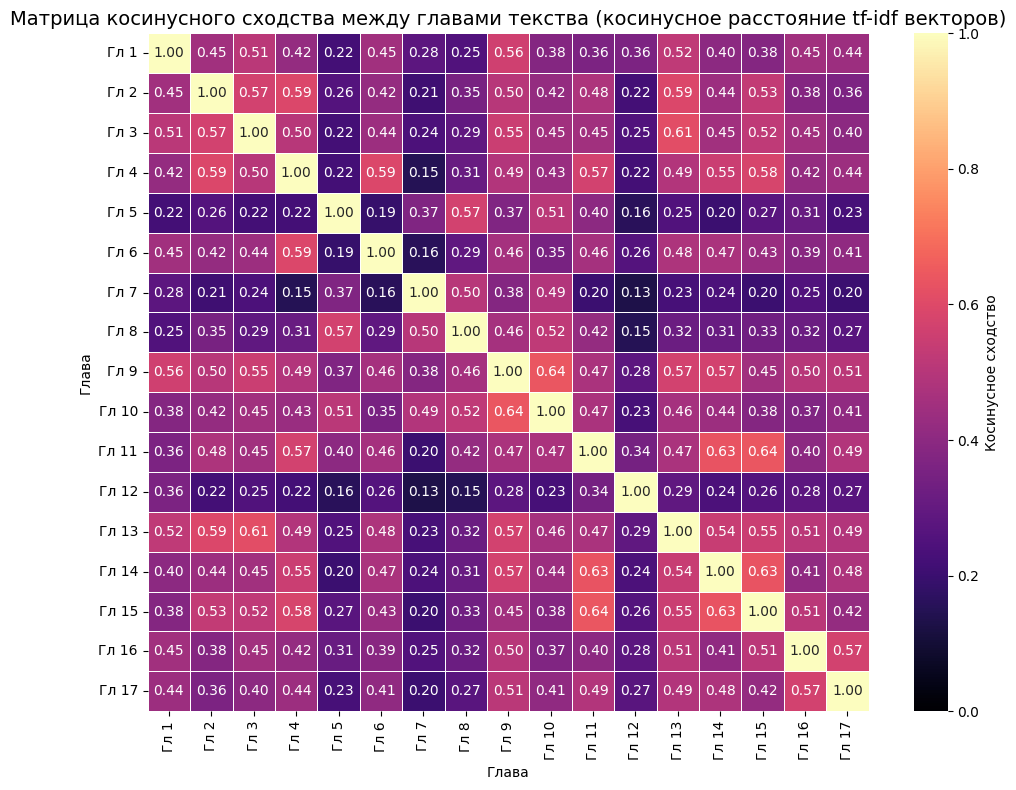

In [85]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.2f',
    cmap='magma',
    vmin=0, vmax=1,
    xticklabels=[f"Гл {i+1}" for i in range(17)],
    yticklabels=[f"Гл {i+1}" for i in range(17)],
    linewidths=0.5,
    cbar_kws={'label': 'Косинусное сходство'}
)

plt.title('Матрица косинусного сходства между главами текства (косинусное расстояние tf-idf векторов)', fontsize=14)
plt.xlabel('Глава')
plt.ylabel('Глава')
plt.tight_layout()
plt.show()

Посмотрим на самые частотные существительные в тексте.

In [69]:
nouns = []
for text in corpus:
    text = re.sub(r'\n', ' ', text)
    text = re.sub('[^а-яА-ЯёЁ -]', '', text.lower())
    lemmatized_text = [morph.parse(tok)[0].normal_form for tok in word_tokenize(text) if morph.parse(tok)[0].tag.POS == 'NOUN']
    text_no_stop = ' '.join([token for token in lemmatized_text if token not in stopwords_ru])
    nouns.append(text_no_stop)
print(nouns[:10])

['глыба грязь благость вельможа державин россия волнение смута пришествие варяг основание империя пётр брань князь набег татарин борьба сосед смятение природа страна ход просвещение житель участь вельможа сила республика обстоятельство область россия народ иго рабство бедствие страна житель дух народность вера память независимость народ огонь язычник время нашествие татарин россия толпа защитник сила отечество любовь независимость чувство самобытность пустынь берег днепр порог камыш засека слово засека укрепление засека место вал ров поле мир республика название сеча течение столетие пришелец родина удалец страна обычай предок нега добыча независимость жизнь наслаждение запорожец женщина пристанище бремя человек война запорожье ничья власть право отечество потомок орда батыев соотчич вельможа бедствие россия житель надежда освобождение народ дух надежда справедливость горький плод угнетение ненависть жажда месть зиновий горсть запорожец притеснитель оружие народ малороссия украина иго 

In [71]:
tfidf_vectorizer_nouns = TfidfVectorizer(ngram_range=(1, 1), min_df=2)
X = tfidf_vectorizer_nouns.fit_transform(nouns)
text_vector_nouns = pd.DataFrame(columns = tfidf_vectorizer_nouns.get_feature_names_out(), data = X.toarray())
text_vector_nouns

,август,ад,адмирал,акт,алексеевич,алексей,алмаз,алтарь,ангел,апостол,...,яд,ядро,язва,язык,яма,ярмарка,ярость,ясневельможность,яство,ящик
0,0.014550,0.000000,0.000000,0.020890,0.015703,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.018738,0.010517,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039385,...,0.000000,0.000000,0.000000,0.024268,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.012612,0.000000,0.000000,0.040836,0.013612,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.009116,0.000000,0.000000,0.000000,0.018108,0.000000,0.000000
3,0.000000,0.014295,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.030997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.013593,0.000000,0.000000,0.000000,0.000000,0.015752,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023672,0.021233,0.000000,...,0.000000,0.000000,0.000000,0.011917,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.069595,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.016768,0.000000,0.000000,0.000000,0.000000,0.033307,0.013606
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018483,0.000000
8,0.038759,0.000000,0.000000,0.000000,0.013944,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.024065,0.000000,0.000000,0.009338,0.000000,0.055775,0.000000,0.018549,0.000000,0.000000
9,0.050080,0.000000,0.000000,0.000000,0.013513,0.013513,0.053927,0.000000,0.000000,0.014687,...,0.000000,0.000000,0.000000,0.000000,0.017976,0.054051,0.000000,0.000000,0.000000,0.044060


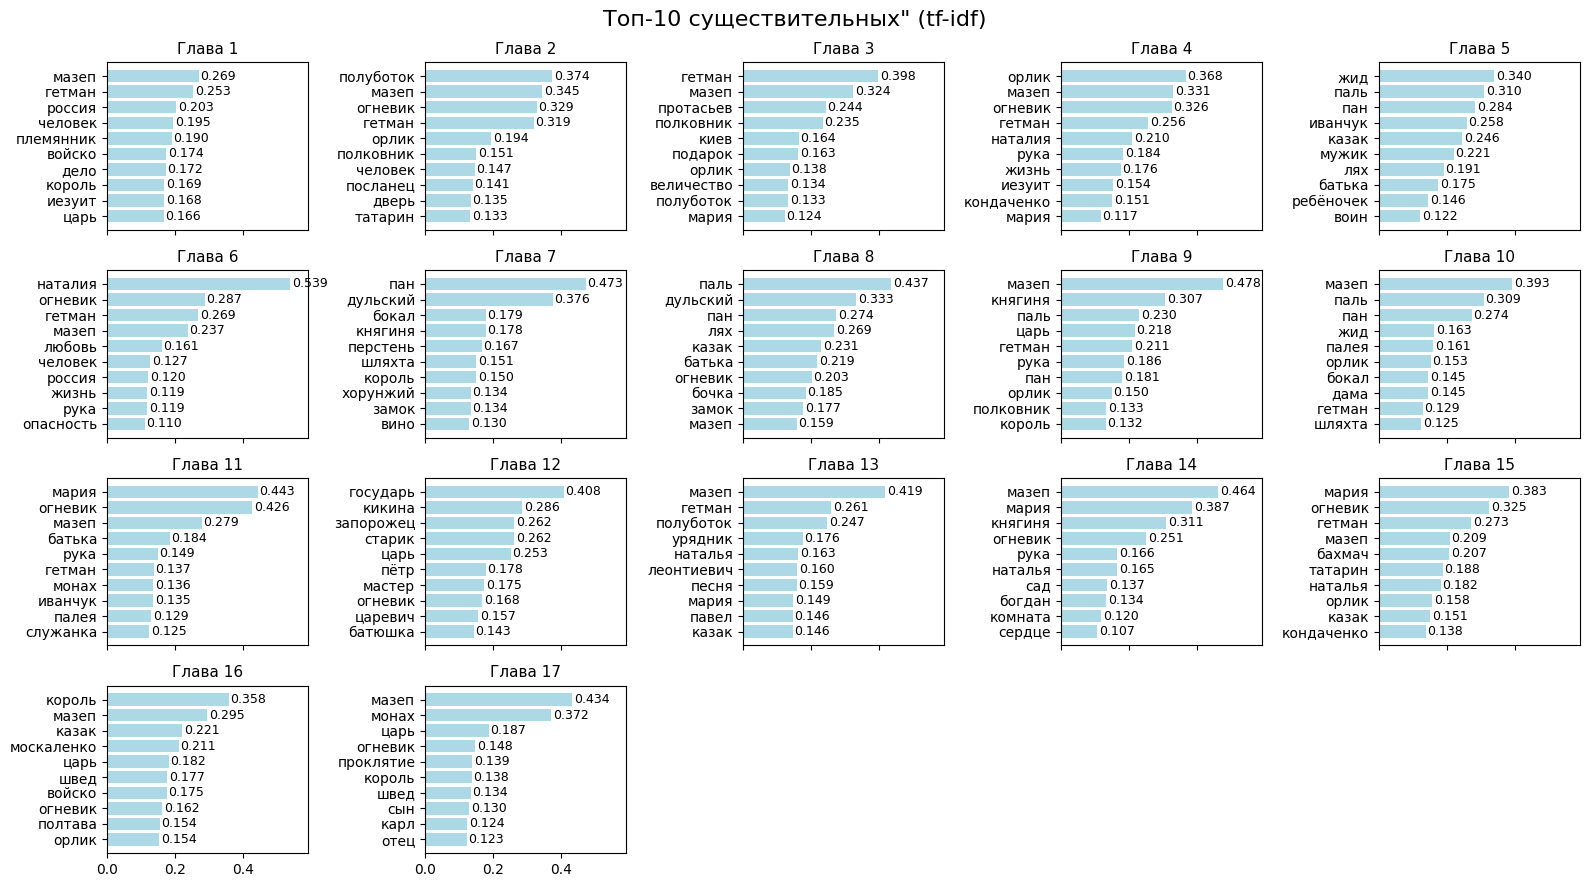

In [79]:
all_top_words = []
all_top_scores = []

for chapter_idx in range(len(nouns)):
    sorted_chapter = sorted(
        zip(tfidf_vectorizer_nouns.get_feature_names_out(), text_vector_nouns.iloc[chapter_idx]),
        key=lambda x: x[1],
        reverse=True
    )

    top_10_reversed = sorted_chapter[:10][::-1] #топ-10
    words = [w[0] for w in top_10_reversed]
    scores = [w[1] for w in top_10_reversed]

    all_top_words.append(words)
    all_top_scores.append(scores)

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(16, 9), sharex=True)
fig.suptitle('Топ-10 cуществительных" (tf-idf)', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i >= len(nouns):
        ax.axis('off')
        continue

    ax.barh(all_top_words[i], all_top_scores[i], color='lightblue')
    ax.set_title(f'Глава {i+1}', fontsize=11)
    ax.set_xlim(0, max(max(scores) for scores in all_top_scores) * 1.1)

    for j, v in enumerate(all_top_scores[i]):
        ax.text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

В тексте мы видим много имен собственных — особенно часто встречается Мазепа (он, видимо, по ошибке лемматизировался как «мазеп») — культурно-исторических терминов, вроде иезуита, гетмана, пана, ляха, шляхта, казак и прочих. На место действия указывают и топонимы: Киев, Полтава. Конечно, больше всего в глаза бросаются слова, связанные с военной сферой: тот же гетман, полковник, огневик, воин, войско и другие.

А теперь посмотрим на прилагательные сразу во всем тексте, не прибегая к TF-IDF.

In [108]:
clean_corpus = ' '.join([''.join(text) for text in clean_text])

In [110]:
def tagger_text(data):
    tagged_list = []
    for word in word_tokenize(data):
        parsed_word = morph.parse(word)[0]
        if parsed_word.tag.POS == 'ADJF' or parsed_word.tag.POS == 'ADJS':
            tagged_list.append((parsed_word.normal_form))
    return tagged_list

In [111]:
tagged_text = tagger_text(clean_corpus)

In [114]:
adj = [item for item in tagged_text]
count = Counter(adj)

In [115]:
from tqdm import tqdm

In [120]:
def rel_freq_list(data):
    verb_lemmas = [item for item in data]
    count = Counter(verb_lemmas)
    rel_frequency_list = []
    for item, freq in tqdm(count.items()):
        rel_freq = round(freq / len(data) * 100, 2)
        rel_frequency_list.append((item, freq, rel_freq))
    rel_frequency_list.sort(key=lambda x: x[1], reverse=True)
    return rel_frequency_list

100%|██████████| 1367/1367 [00:00<00:00, 492071.20it/s]


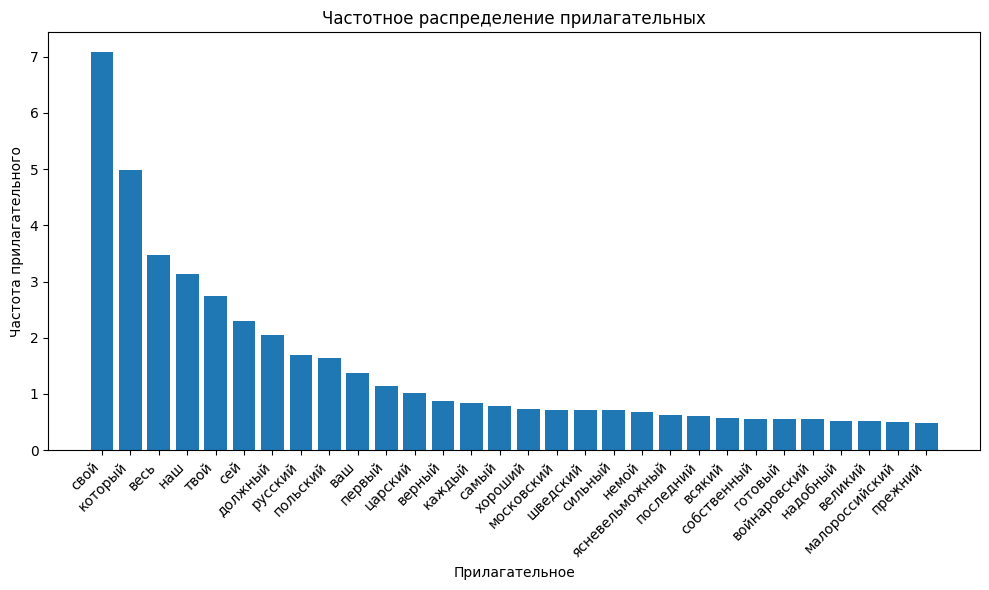

In [122]:
items = [item for item, freq, rel_freq in rel_freq_list(tagged_text)[:30]]
frequencies = [rel_freq for item, freq, rel_freq in rel_freq_list(tagged_text)[:30]]

plt.figure(figsize=(10, 6))
plt.bar(items, frequencies)
plt.xlabel("Прилагательное")
plt.ylabel("Частота прилагательного")
plt.title("Частотное распределение прилагательных")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Проигнорируем местоименные прилагательные и вместо них посмотрим на остальные. Здесь мы видим много слов, относящихся к обозначению национальности: русский (лидирует среди всех), польский, шведский, малороссийский. Судя по этой таблице и тем барчартам, которые получились с существительными, текст, вероятнее всего написан русским автором — очень часто встречаются слова вроде "царь", "государь" и производные, слова "русский" и "московский" встречаются чаще остальных, хотя очевидно по списку существительных, что произведение предполагает скорее польско-украинский сеттинг (затрагивая частично походы Петра I и Полтавскую битву).

# Коллокации

In [124]:
import nltk
from nltk.collocations import *
from nltk.tokenize import sent_tokenize

In [135]:
bigram_measures = nltk.collocations.BigramAssocMeasures()
finder_big = BigramCollocationFinder.from_words(word_tokenize(clean_corpus))

Посмотрим коллокации по различным метрикам.

In [137]:
finder_big.score_ngrams(bigram_measures.student_t)[:20]

[(('сказать', 'мазеп'), 8.285468636747424),
 (('пан', 'дульский'), 7.818244740830334),
 (('ясневельможный', 'гетман'), 6.568705867804245),
 (('пан', 'гетман'), 6.566413220189543),
 (('патер', 'заленский'), 6.3969797326104345),
 (('царь', 'московский'), 5.947279002807733),
 (('сказать', 'паль'), 5.833301477626694),
 (('сказать', 'огневик'), 5.733345708261373),
 (('белый', 'церковь'), 5.188129797044304),
 (('возразить', 'мазеп'), 5.040445583008543),
 (('король', 'шведский'), 4.859846291065824),
 (('русский', 'царь'), 4.642256445455779),
 (('взять', 'рука'), 4.585952479842189),
 (('царский', 'величество'), 4.568635850115756),
 (('это', 'время'), 4.536106771643723),
 (('примолвить', 'мазеп'), 4.489453525505928),
 (('малороссия', 'украина'), 4.442448080712764),
 (('войско', 'малороссийский'), 4.441048463794609),
 (('всё', 'это'), 4.42916107802636),
 (('говорить', 'слово'), 4.369060167335658)]

In [138]:
finder_big.score_ngrams(bigram_measures.likelihood_ratio)[:20]

[(('патер', 'заленский'), 604.8076796782594),
 (('пан', 'дульский'), 561.7246523557315),
 (('ясневельможный', 'гетман'), 374.15044119447265),
 (('белый', 'церковь'), 337.10488488430565),
 (('павел', 'леонтиевич'), 333.56595397041),
 (('царь', 'московский'), 298.47951985466045),
 (('сказать', 'мазеп'), 248.94296408283554),
 (('царский', 'величество'), 221.17505583461792),
 (('пан', 'гетман'), 220.8177285749092),
 (('пётр', 'великий'), 198.22811048345386),
 (('король', 'шведский'), 197.68472001505637),
 (('княгиня', 'дульскай'), 194.2248427956478),
 (('станислав', 'лещинский'), 188.09783545462238),
 (('войско', 'малороссийский'), 171.68216024914244),
 (('малороссия', 'украина'), 171.43199193845578),
 (('король', 'станислав'), 161.60964356943663),
 (('генеральный', 'старшина'), 156.07527244863093),
 (('старшина', 'полковник'), 140.97793770347926),
 (('покачать', 'голова'), 140.41975855864007),
 (('сказать', 'паль'), 138.35941744699198)]

In [139]:
finder_big.score_ngrams(bigram_measures.pmi)[:20]

[(('аббат', 'капитул'), 15.77099934038398),
 (('алларт', 'беллинга'), 15.77099934038398),
 (('алом', 'атласный'), 15.77099934038398),
 (('англичанин', 'гордон'), 15.77099934038398),
 (('антихрист', 'папа'), 15.77099934038398),
 (('антоний', 'глотать'), 15.77099934038398),
 (('архимедовый', 'рычаг'), 15.77099934038398),
 (('бахий', 'пернамбукий'), 15.77099934038398),
 (('бахма', 'ча'), 15.77099934038398),
 (('белые', 'снег'), 15.77099934038398),
 (('бенедиктин', 'бернардин'), 15.77099934038398),
 (('бернардин', 'реформат'), 15.77099934038398),
 (('беспамятство', 'онемение'), 15.77099934038398),
 (('беспримерный', 'дотоль'), 15.77099934038398),
 (('битый', 'темя'), 15.77099934038398),
 (('благодетельный', 'роса'), 15.77099934038398),
 (('богданович', 'глеб'), 15.77099934038398),
 (('богословский', 'прение'), 15.77099934038398),
 (('богуслав', 'корсунуть'), 15.77099934038398),
 (('бомбардирский', 'рота'), 15.77099934038398)]

# Синтаксис

Здесь мы не будем смотреть на весь текст, а возьмем отдельно взятую главу — седьмую. Признаюсь честно, меня просто привлекли в ней самые частотные существительны: «бокал», «перстень», «замок», «вино». Она как будто немного выбивается из ряда остальных глав.

In [145]:
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 88.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [146]:
nlp_ru = spacy.load("ru_core_news_sm")

Сначала найдем самое длинное предложение — его мы изобразим на схеме.

In [149]:
from nltk.tokenize import sent_tokenize

chapter_sent = sent_tokenize(corpus[6])
chapter_sent

['\r\n\r\nУже из давних лет замечено у всех,\r\nГде лад, там и успех;\r\nА от раздора все на свете погибает.',
 'Хемницер\r\n\r\n   В наше время едва можно поверить, чтоб такой образ правления, как был в прежней Польше, мог существовать между образованными народами!',
 'Избирательные короли, принимая бразды правления на условиях, предложенных избирателями, никогда не исполняли оных, не имея ни власти законодательной, ни силы во власти исполнительной.',
 'Паны содержали в рабстве народ и в подчиненности равную себе по правам, но бедную шляхту.',
 'Богатые властители земель были независимые владетели в своих помыслах, содержали свое надворное войско, не слушались законов, противились вооруженною рукою исполнению судейских приговоров, самоуправлялись со своими соседями и повиновались королю тогда только, когда надеялись получить милости, ибо наконец вся власть короля ограничивалась раздачею чинов, мест и казенных имуществ, или старосте.',
 'Сопротивление королевской воле не почиталось даж

In [151]:
index, longest_sentence = max(enumerate(chapter_sent), key=lambda x: len(x[1]))
print(f"Индекс: {index}")
print(f"Предложение: {longest_sentence}")

Индекс: 234
Предложение: Знавшим Дорошинского известно было, что он надевал сии драгоценные вещи только в необыкновенных случаях, как будто для выказывания своего могущества; а потому, когда он явился в зале в светло-зеленом бархатном кунтуше, в алом атласном жупане, подпоясанный парчовым персидским кушаком и в лучших своих алмазных украшениях, хитрая княгиня Дульская тотчас догадалась, что холодность Дорошинского притворная и что он желает нравиться и обратить на себя внимание.


Теперь разметим всю главу и найдем все глаголы.

In [147]:
chapter = nlp_ru(corpus[6])

In [148]:
def synt_table(txt, dep, head):
    f_texts = [token.text for token in txt]
    f_deps = [token.dep_ for token in txt]
    f_heads = [token.head.text for token in txt]
    f_heads_pos = [token.head.pos_ for token in txt]
    f_children_t = [[child for child in token.children] for token in txt]

    df_f = pd.DataFrame({'token': f_texts,
                   'deprel': f_deps,
                   'head': f_heads,
                   'head_pos': f_heads_pos,
                   'children': f_children_t
                    })


    targs = []
    for possible_subject in txt:
       if possible_subject.dep_ == str(dep) and possible_subject.head.pos_ == str(head):
            targs.append(possible_subject.head)


    return df_f, targs

In [152]:
result_sh = synt_table(chapter, 'nsubj', 'VERB')

result_sh[0]

,token,deprel,head,head_pos,children
0,\r\n\r\n,dep,Уже,ADV,[]
1,Уже,advmod,лет,NOUN,[\r\n\r\n]
2,из,case,лет,NOUN,[]
3,давних,amod,лет,NOUN,[]
4,лет,obl,замечено,VERB,"[Уже, из, давних]"
...,...,...,...,...,...
6304,в,case,окна,NOUN,[]
6305,разбитые,amod,окна,NOUN,[]
6306,окна,obl,свистел,VERB,"[в, разбитые]"
6307,.,punct,ревела,VERB,[\r\n \r\n]


In [153]:
result_sh[1]

[погибает,
 мог,
 исполняли,
 содержали,
 противились,
 ограничивалась,
 почиталось,
 нарушал,
 вымышлял,
 бродила,
 походила,
 зависело,
 составляли,
 кипело,
 хотел,
 стремился,
 избирались,
 избирались,
 назывались,
 признавали,
 есть,
 есть,
 дошли,
 открыл,
 пылала,
 признавало,
 нет,
 происходят,
 носил,
 есть,
 убедил,
 смели,
 поддерживал,
 влюбился,
 вознамерился,
 ожидал,
 вел,
 жил,
 имели,
 измерялась,
 противупоставляла,
 торжествовали,
 почиталась,
 вела,
 хотел,
 вооружались,
 почитал,
 находилось,
 беспокоило,
 вознамерился,
 носился,
 хранились,
 выслал,
 решился,
 видели,
 ожидал,
 показался,
 привел,
 грозил,
 дал,
 стали,
 признался,
 идет,
 объявил,
 собрал,
 собрались,
 рассказал,
 воскликнул,
 улыбнулся,
 хочет,
 стоить,
 сказал,
 доживает,
 составляете,
 составляете,
 верю,
 сказал,
 собрались,
 ускользнул,
 будет,
 сохраним,
 зависит,
 примолвил,
 требует,
 примолвил,
 могу,
 зависит,
 дадут,
 думаю,
 простираете,
 было,
 считал,
 считал,
 разбивали,
 приходило

Изобразим схематично самое длинное предложение в главе.

In [154]:
from spacy import displacy

In [162]:
sent = chapter_sent[234]

displacy.render(nlp_ru(sent), style="dep", options={
        "add_lemma": True,
        "compact": True,
        "distance": 100,
        "collapse_punct": True
    })

Из забавного заметила, что «светло-зеленый» здесь разделилось на два слова с разными ролями.

# Итоги

Здесь я напишу то, о чем не сказала раннее.

1. Жанр, скорее всего, либо роман, либо повесть.
2. Действие в тексте происходит в XVIII в., но сам текст написан, как я полагаю, в XIX в. —— об этом говорит и лексика, и жанр: целом интерес к национальной (и имперской тоже) истории не характерен для предыдущего столетия.
3. Текст затрагивает военные действия и жизнь военных людей того времени, но он совершенно точно не крутится только вокруг этого. Я бы сказала, что это что-то вроде художественной биографии Мазепы —— полагаю, он здесь главный герой, судя по тому, как часто он встречается.
4. Насчет эмоциональной окраски сказать что-то конкретное трудно, но текст точно не лишен пафосности. Это видно по выбору прилагательных: «должный», «верный», «хороший», «великий».

Интересно, что нигде не попадается слово «предатель» и его производные и синонимы. Текст про Мазепу, а в советской и современной российской историографии он описывается скорее именно так, но совершенно точно не в этом художественном произведении. Я не знаю, влияет ли на это тот факт, что текст написан в Российской империи, где, возможно, к его фигуре было иное отношение, или же это представление автора.
